## PyTomography Reconstruction with OSEM 3i:15s

#### Import packages

In [1]:
from __future__ import annotations
import torch
import pytomography
from pytomography.metadata import ObjectMeta
from pytomography.metadata.PET import PETLMProjMeta
from pytomography.projectors.PET import PETLMSystemMatrix
from pytomography.algorithms import OSEM, OSMAPOSL
from pytomography.io.PET import gate, shared
from pytomography.likelihoods import PoissonLogLikelihood
import os
from pytomography.transforms.shared import GaussianFilter
import matplotlib.pyplot as plt
from pytomography.utils import sss
import parallelproj
import numpy as np
from pytomography.priors import RelativeDifferencePrior
from pytomography.priors import TopNAnatomyNeighbourWeight
from pytomography.metadata.PET import PETLMProjMeta, PETTOFMeta
import gc

from nibabel import Nifti1Image
from pytomography.callbacks import DataStorageCallback
import nibabel as nib

#### Load GATE files

In [2]:
LOAD_FROM_ROOT = False # Set to true if .pt files not generated

#### PET Scanner information

In [3]:
# Path where the file is located
path = '/home/administrator/Secretária/ResultsY90'
# Uploading root files from the simulation
macro_path = os.path.join(path, 'GeometryPETVereos.mac')  
# Get information dictionary about the PET scanner - had to be changed because the order defined in PET VEREOS scanner was different from the defined by pytomography 'crystal', 'submodule', 'module', 'rsector', 'world'
pet_info = gate.get_detector_info(
    path = macro_path,
    mean_interaction_depth=7.7,
    min_rsector_difference = 0
)

# We can look at the information of our PET scanner:
print(pet_info)

{'min_rsector_difference': 0, 'crystal_length': 19.0, 'radius': 389.7, 'crystalTransNr': 2, 'crystalTransSpacing': 4.0, 'crystalAxialNr': 2, 'crystalAxialSpacing': 4.0, 'submoduleTransNr': 4, 'submoduleTransSpacing': 8.0, 'submoduleAxialNr': 4, 'submoduleAxialSpacing': 8.0, 'moduleTransNr': 4, 'moduleTransSpacing': 32.85, 'moduleAxialNr': 5, 'moduleAxialSpacing': 32.85, 'rsectorTransNr': 18, 'rsectorAxialNr': 1, 'NrCrystalsPerRing': 576, 'NrRings': 40, 'firstCrystalAxis': 1}


#### Normalization correction

In [4]:
# Once it is ran, the normalization weights corresponding to each pair of detector IDs will be obtained (due to geometry/crystal orientation).
if LOAD_FROM_ROOT:
    normalization_paths = [os.path.join(path, '/home/administrator/Secretária/ResultsY90/PetVereoslistmode_normalization.root')]

    # Get normalization weights for all possible detector ID pairs
    # Function to get sensitivty factor from a cylindrical calibration phantom
    normalization_weights = gate.get_normalization_weights_cylinder_calibration(
        normalization_paths,
        pet_info,
        cylinder_radius = 349, # mm radius of the thin cylindrical shell used for calibration
        include_randoms=False
    )

    torch.save(normalization_weights, os.path.join(path, 'normalization_weights_noTOF.pt'))
normalization_weights = torch.load(os.path.join(path, 'normalization_weights_noTOF.pt'))

#### ROOT upload files

In [5]:
# Paths to ROOT files containing data
path_root = '/home/administrator/Secretária/ResultsY90/'
paths = [os.path.join(path_root, 'PetVereoslistmode_Y90.root')]

##### True Coincidences

In [6]:
if LOAD_FROM_ROOT:
    detector_trues_ids = gate.get_detector_ids_from_root(
        paths,
        pet_info,
        include_randoms=False,
        include_scatters=False)
    torch.save(detector_trues_ids, os.path.join(path, 'detector_ids_trues_only.pt'))
detector_trues_ids = torch.load(os.path.join(path, 'detector_ids_trues_only.pt'))
print(f"Found {len(detector_trues_ids)} True coincidences")
print("Saved True Events to file")

Found 6144020 True coincidences
Saved True Events to file


##### Randoms and Scatters Coincidences

In [7]:
if LOAD_FROM_ROOT:
    detector_ids_true_randoms = gate.get_detector_ids_from_root(
        paths,
        pet_info,
        randoms_only=True)
    detector_ids_true_scatters = gate.get_detector_ids_from_root(
        paths,
        pet_info,
        scatters_only=True)
    torch.save(detector_ids_true_randoms, os.path.join(path, 'detector_ids_true_randoms.pt'))
    torch.save(detector_ids_true_scatters, os.path.join(path, 'detector_ids_true_scatters.pt'))
detector_ids_true_randoms = torch.load(os.path.join(path, 'detector_ids_true_randoms.pt'))
detector_ids_true_scatters = torch.load(os.path.join(path, 'detector_ids_true_scatters.pt'))
print(f"Found {len(detector_ids_true_randoms)} Random coincidences")
print(f"Found {len(detector_ids_true_scatters)} Scatter coincidences")
print("Saved Randoms and Scatters true events to files")

Found 137008 Random coincidences
Found 2328200 Scatter coincidences
Saved Randoms and Scatters true events to files


### True Coincidences Reconstruction - 6 PSF, 3i:15s, normalization and attenuation correction

In [8]:
# Specify where to save the files FIRST
save_directory = "/home/administrator/Secretária/ResultsY90/results_notof_primary"
os.makedirs(save_directory, exist_ok=True)
print(f"Files will be saved to: {save_directory}")

## RECONSTRUCTION

# Specify object space for reconstruction
object_meta = ObjectMeta(
    dr=(2.21,2.21,2.21), # voxel size
    shape=(125,122,93) # dimensions
)

# Get projection space metadata from PET geometry information dictionary
proj_meta = PETLMProjMeta(
    detector_trues_ids, # list of all detected True coincidences detector ID pairs
    pet_info,  # scanner information
    weights_sensitivity=normalization_weights # normalization coefficients
    )

# Get attenuation map - same image interfile format as CASToR
atten_map = gate.get_aligned_attenuation_map(os.path.join(path, 'attenuation_image-HU.hdr'), object_meta).to(pytomography.device)

# point spread function - model based correction built into the system matrix that accounts for the intrinsic blurring in the pet system
# Applies a Gaussian smoothing filter to the reconstructed object with the specified full-width-half-max (FWHM)
# when n_sigmas is not given, it uses the default: n_sigmas = 3
# n_sigmas just decides how far out we go before cutting off the Gaussian.
psf_transform = GaussianFilter(6,3) # 6 mm FWHM gaussian 

# Create system matrix.
system_matrix = PETLMSystemMatrix(
    object_meta,
    proj_meta,
    obj2obj_transforms = [psf_transform],
    attenuation_map = atten_map,
    N_splits=8,
)

# Create likelihood. For listmode reconstruction, projections don't need to be provided, since all detection events are stored in proj_meta
likelihood = PoissonLogLikelihood(
    system_matrix
)

# Initialize reconstruction algorithm OSEM
recon_algorithm = OSEM(likelihood)

## CALLBACK TO SAVE RESULTS

# Create initial object for the callback
#object_initial = torch.ones(object_meta.shape, device=pytomography.device)

# Create DataStorageCallback to save all iterations
# function creates a copy of a tensor. In your callback setup, it's used correctly to preserve the initial state of the reconstruction algorithm's object prediction.
data_storage_callback = DataStorageCallback(likelihood, torch.clone(recon_algorithm.object_prediction))

# Reconstruction parameters - iterations and subsets
recon_trues_only = recon_algorithm(n_iters=3, n_subsets=15, callback=data_storage_callback)

Files will be saved to: /home/administrator/Secretária/ResultsY90/results_notof_primary


#### Visualization of final image

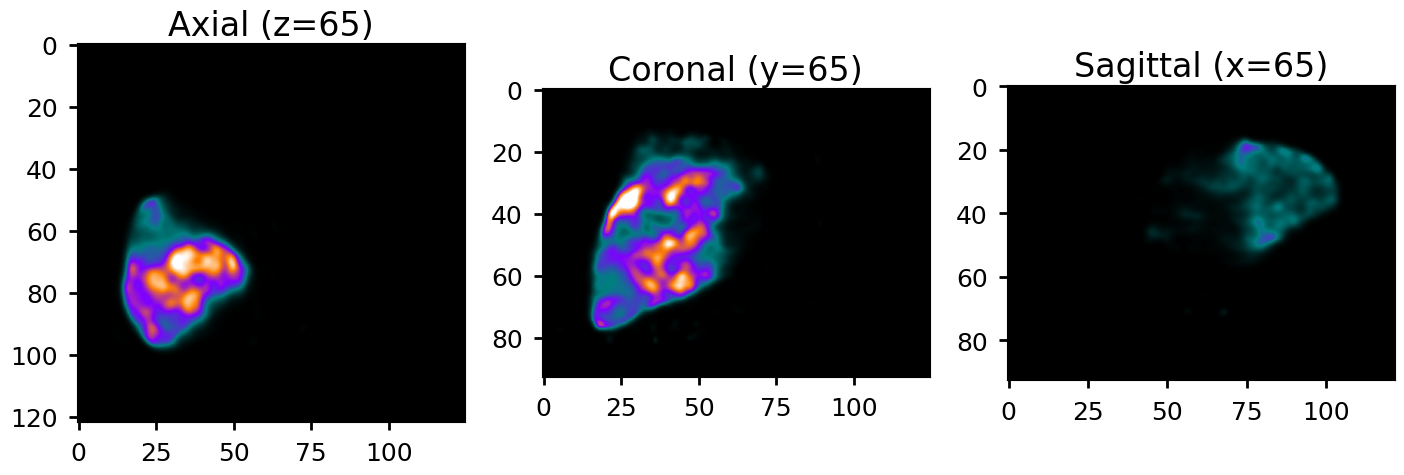

In [9]:
import matplotlib.colors as mcolors

# 1. Define your custom color list (positions from 0 to 1)
slicer_pet_colors = [
    (0.00, "#000000"),  # Black
    (0.25, "#008080"),  # Teal / Dark Cyan
    (0.50, "#8000ff"),  # Purple / Violet
    (0.75, "#ff8000"),  # Orange
    (1.00, "#ffffff")   # White
]

# 2. Create the custom colormap object
cmap = mcolors.LinearSegmentedColormap.from_list('SlicerPET', slicer_pet_colors)

vmax = 15
slice_idx = 65

fig, ax = plt.subplots(1, 3, figsize=(17, 8), gridspec_kw={'wspace': 0.2})

# Plotting each plane
ax[0].imshow(recon_trues_only[:, :, slice_idx].cpu().T, cmap=cmap,
             interpolation='gaussian', vmax=vmax, origin='upper')
ax[0].set_title(f'Axial (z={slice_idx})', fontsize=24) # Increased title size too

ax[1].imshow(recon_trues_only[:, slice_idx, :].cpu().T, cmap=cmap,
             interpolation='gaussian', vmax=vmax, origin='upper')
ax[1].set_title(f'Coronal (y={slice_idx})', fontsize=24)

ax[2].imshow(recon_trues_only[slice_idx, :, :].cpu().T, cmap=cmap,
             interpolation='gaussian', vmax=vmax, origin='upper')
ax[2].set_title(f'Sagittal (x={slice_idx})', fontsize=24)

# --- INCREASE AXIS NUMBER SIZE ---
for a in ax:
    # labelsize adjusts the numbers; width/length adjusts the tick marks
    a.tick_params(axis='both', which='major', labelsize=18, width=2, length=6)
    # If you want to force specific spacing/padding between numbers and the plot:
    a.tick_params(axis='both', pad=8)

fig.tight_layout()
plt.subplots_adjust(wspace=0.3) # Adjusted slightly for larger labels
plt.show()

#### Save main iterations and aligned them for posterior segmentations analysis
##### Conversion from tensor to NIfTI format

In [10]:
import nibabel as nib
import torch
import numpy as np
import os

# --- SETTINGS ---
n_subsets = 15
n_main_iters = 3  # total OSEM iterations
save_directory = "/home/administrator/Secretária/ResultsY90/Results_PrimaryTrues3i15s"
os.makedirs(save_directory, exist_ok=True)
print(f"Files will be saved to: {save_directory}\n")

# --- FILTER MAIN ITERATIONS ---
main_iterations = []
print(f"Total objects in callback: {len(data_storage_callback.objects)}")

for i in range(n_main_iters):
    main_idx = (i * n_subsets) + (n_subsets - 1)  # last subset of each iteration
    if main_idx < len(data_storage_callback.objects):
        main_iterations.append(data_storage_callback.objects[main_idx])
        print(f"Main iteration {i+1} found at index {main_idx}")
    else:
        print(f"Warning: Main iteration {i+1} index {main_idx} out of range")

print(f"\nFiltered {len(data_storage_callback.objects)} total objects → {len(main_iterations)} main iterations.\n")

# --- VOXEL METADATA ---
voxel_size = object_meta.dr  # (dx, dy, dz)
print(f"Voxel size: {voxel_size}")

# --- PROCESS AND SAVE EACH MAIN ITERATION ---
for i, tensor in enumerate(main_iterations, start=1):
    recon_np = tensor.detach().cpu().numpy()

    # --- FIX ORIENTATION ---
    recon_np = np.flip(recon_np, axis=1)  # flip Y
    recon_np = np.flip(recon_np, axis=0)  # flip X
    recon_np = np.flip(recon_np, axis=2)  # flip Z

    # --- CREATE AFFINE ---
    affine = np.diag([voxel_size[0], voxel_size[1], voxel_size[2], 1])

    # --- CREATE NIFTI ---
    nifti_img = nib.Nifti1Image(recon_np, affine)
    nifti_img.header.set_zooms(voxel_size)
    nifti_img.header['descrip'] = f"OSEM reconstruction - Iteration {i} (flipped X,Y,Z)"

    # --- SAVE ---
    file_path = os.path.join(save_directory, f"reconstruction_iteration_{i}.nii")
    nib.save(nifti_img, file_path)
    print(f"Saved main iteration {i} to: {file_path}")

# --- VERIFY FILES ---
print(f"\nChecking files in: {save_directory}")
for file in os.listdir(save_directory):
    if file.startswith("reconstruction_iteration_") and file.endswith(".nii"):
        file_path = os.path.join(save_directory, file)
        size_mb = os.path.getsize(file_path) / (1024 * 1024)
        print(f"  {file} ({size_mb:.2f} MB)")

print("\nAll main iteration files created with correct orientation and affine matrix.")

Files will be saved to: /home/administrator/Secretária/ResultsY90/Results_PrimaryTrues3i15s

Total objects in callback: 46
Main iteration 1 found at index 14
Main iteration 2 found at index 29
Main iteration 3 found at index 44

Filtered 46 total objects → 3 main iterations.

Voxel size: (2.21, 2.21, 2.21)
Saved main iteration 1 to: /home/administrator/Secretária/ResultsY90/Results_PrimaryTrues3i15s/reconstruction_iteration_1.nii
Saved main iteration 2 to: /home/administrator/Secretária/ResultsY90/Results_PrimaryTrues3i15s/reconstruction_iteration_2.nii
Saved main iteration 3 to: /home/administrator/Secretária/ResultsY90/Results_PrimaryTrues3i15s/reconstruction_iteration_3.nii

Checking files in: /home/administrator/Secretária/ResultsY90/Results_PrimaryTrues3i15s
  reconstruction_iteration_1.nii (5.41 MB)
  reconstruction_iteration_2.nii (5.41 MB)
  reconstruction_iteration_3.nii (5.41 MB)

All main iteration files created with correct orientation and affine matrix.


#### Visualize all iterations image results

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import os
from matplotlib.colors import LinearSegmentedColormap
from ipywidgets import interact, IntSlider, widgets

# ============================================================
# 1. Path Configuration & Data Loading
# ============================================================
base_dir = os.path.expanduser("/home/administrator/Secretária/ResultsY90/Results_PrimaryTrues3i15s")

# Load 3 iterations dynamically
recon_paths = [os.path.join(base_dir, f"reconstruction_iteration_{i}.nii") for i in range(1, 4)]

iterations_data = []
iterations_labels = []

for idx, file_path in enumerate(recon_paths, start=1):
    if os.path.exists(file_path):
        img = nib.load(file_path)
        iterations_data.append(img.get_fdata())
        iterations_labels.append(f'Iteration {idx}')
    else:
        print(f"Warning: File not found - {file_path}")

if not iterations_data:
    raise RuntimeError("No reconstruction files were loaded.")

# ============================================================
# 2. Custom Colormap Definition (3D Slicer "PET-DICOM")
# ============================================================
slicer_pet_colors = [
    (0.00, "#000000"),  # 0%: Black
    (0.25, "#008080"),  # 25%: Teal / Dark Cyan
    (0.50, "#8000ff"),  # 50%: Purple / Violet
    (0.75, "#ff8000"),  # 75%: Orange
    (1.00, "#ffffff")   # 100%: White
]
pet_cmap = LinearSegmentedColormap.from_list("Slicer_PET_DICOM", slicer_pet_colors)

# ============================================================
# 3. Enhanced Visualization Function
# ============================================================
def plot_reconstructions_enhanced(axial_slice=None, sagittal_slice=None, coronal_slice=None, individual_scaling=False):
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Liberation Serif"],
        "mathtext.fontset": "dejavuserif",
    })

    # Slice defaults
    shape = iterations_data[0].shape
    axial_slice = axial_slice if axial_slice is not None else shape[2] // 2
    sagittal_slice = sagittal_slice if sagittal_slice is not None else shape[0] // 2
    coronal_slice = coronal_slice if coronal_slice is not None else shape[1] // 2

    # Scaling logic
    fixed_vmax = 13.9  
    if individual_scaling:
        vmax_values = [np.percentile(d, 99.9) for d in iterations_data]
    else:
        vmax_values = [fixed_vmax] * len(iterations_data)

    num_iter = len(iterations_data)
    fig, axes = plt.subplots(num_iter, 3, figsize=(16, 4 * num_iter))
    fig.subplots_adjust(top=0.88, bottom=0.08, left=0.15, right=0.9, wspace=0.03, hspace=0.08)

    for row, (data, label, vmax) in enumerate(zip(iterations_data, iterations_labels, vmax_values)):
        # Sagittal 
        sagittal_img = np.rot90(data[sagittal_slice, :, :]) 
        axes[row, 0].imshow(sagittal_img, cmap=pet_cmap, vmin=0, vmax=vmax,
                            interpolation='bicubic', origin='upper', aspect='auto')
        axes[row, 0].axis('off')

        # Coronal
        coronal_img = np.rot90(np.flip(data[:, coronal_slice, :], axis=0))
        axes[row, 1].imshow(coronal_img, cmap=pet_cmap, vmin=0, vmax=vmax,
                            interpolation='bicubic', origin='upper', aspect='auto')
        axes[row, 1].axis('off')

        # Axial
        axial_img = np.rot90(np.flip(data[:, :, axial_slice], axis=0))
        im = axes[row, 2].imshow(axial_img, cmap=pet_cmap, vmin=0, vmax=vmax,
                                 interpolation='bicubic', origin='upper', aspect='auto')
        axes[row, 2].axis('off')

        # Vertical Labels (centered to each row)
        bbox = axes[row, 0].get_position()
        y_center = (bbox.y0 + bbox.y1) / 2
        fig.text(0.08, y_center, label, fontsize=18, weight='bold', rotation=90, 
                 va='center', ha='center',
                 bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="black", alpha=0.8))

    # Titles for the top row
    titles = [f'Sagittal (X={sagittal_slice})', f'Coronal (Y={coronal_slice})', f'Axial (Z={axial_slice})']
    for i, title in enumerate(titles):
        axes[0, i].set_title(title, fontsize=14, pad=15, weight='bold')

    plt.suptitle('OSEM Primary-only Reconstruction: Iteration Comparison', fontsize=18, weight='bold', y=0.96)

    # Shared Colorbar
    # Equally spaced colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    custom_ticks = [0.0, 3.5, 6.9, 10.4, 13.9]
    cbar = fig.colorbar(im, cax=cbar_ax, ticks=custom_ticks, format='%.1f')
    cbar.set_label('Intensity', labelpad=20, fontsize=18, weight='bold')
    cbar.ax.tick_params(labelsize=14)

    plt.show()

# ============================================================
# 4. Interactive Widgets
# ============================================================
x_dim, y_dim, z_dim = iterations_data[0].shape # Mapping dims to sliders

interact(
    plot_reconstructions_enhanced,
    sagittal_slice=IntSlider(min=0, max=x_dim-1, step=1, value=x_dim//2, description='Sagittal:'),
    coronal_slice=IntSlider(min=0, max=y_dim-1, step=1, value=y_dim//2, description='Coronal:'),
    axial_slice=IntSlider(min=0, max=z_dim-1, step=1, value=z_dim//2, description='Axial:'),
    individual_scaling=widgets.Checkbox(value=False, description='Individual Scaling')
);

interactive(children=(IntSlider(value=46, description='Axial:', max=92), IntSlider(value=62, description='Sagi…

### Reconstruction With Random and Scatter Estimation

#### Total Coincidences

In [12]:
if LOAD_FROM_ROOT:
    detector_total_ids = gate.get_detector_ids_from_root(
        paths,
        pet_info)
    torch.save(detector_total_ids, os.path.join(path, 'detector_ids_totalnotof_events.pt'))
detector_total_ids = torch.load(os.path.join(path, 'detector_ids_totalnotof_events.pt'))
print(f"Found {len(detector_total_ids)} Total events")
print("Saved total events to files")

Found 8609228 Total events
Saved total events to files


### Randoms Estimation via Listmode (PyTomography Workflow)

PyTomography provides tools to estimate **random coincidences** using **delayed events**.
The typical workflow consists of four main steps:

1. **Load the listmode ROOT file** containing all **delayed coincidences** (random events).
2. **Convert the delayed events** from listmode format into a **sinogram** representation.
3. **Apply smoothing** to the randoms sinogram to reduce statistical noise.
4. **Convert the smoothed sinogram** back into a **listmode file** for subsequent corrections or reconstruction steps.


In [13]:
# Open listmode of all delayed events
if LOAD_FROM_ROOT:
    detector_ids_randoms = gate.get_detector_ids_from_root(
        paths,
        pet_info,
        substr = 'Delay')
    torch.save(detector_ids_randoms, os.path.join(path, 'detector_ids_delays_notof.pt'))
detector_ids_randoms= torch.load(os.path.join(path, 'detector_ids_delays_notof.pt'))
print(f"Found {len(detector_ids_randoms)} random events")
print("Saved total random to files")

Found 148152 random events
Saved total random to files


In [14]:
# Convert these to a sinogram
# sinogram order is (r, θ, z)
sinogram_delays = gate.listmode_to_sinogram(detector_ids_randoms, pet_info)
print("Original sinogram shape:", sinogram_delays.shape)

Original sinogram shape: torch.Size([288, 577, 1600])


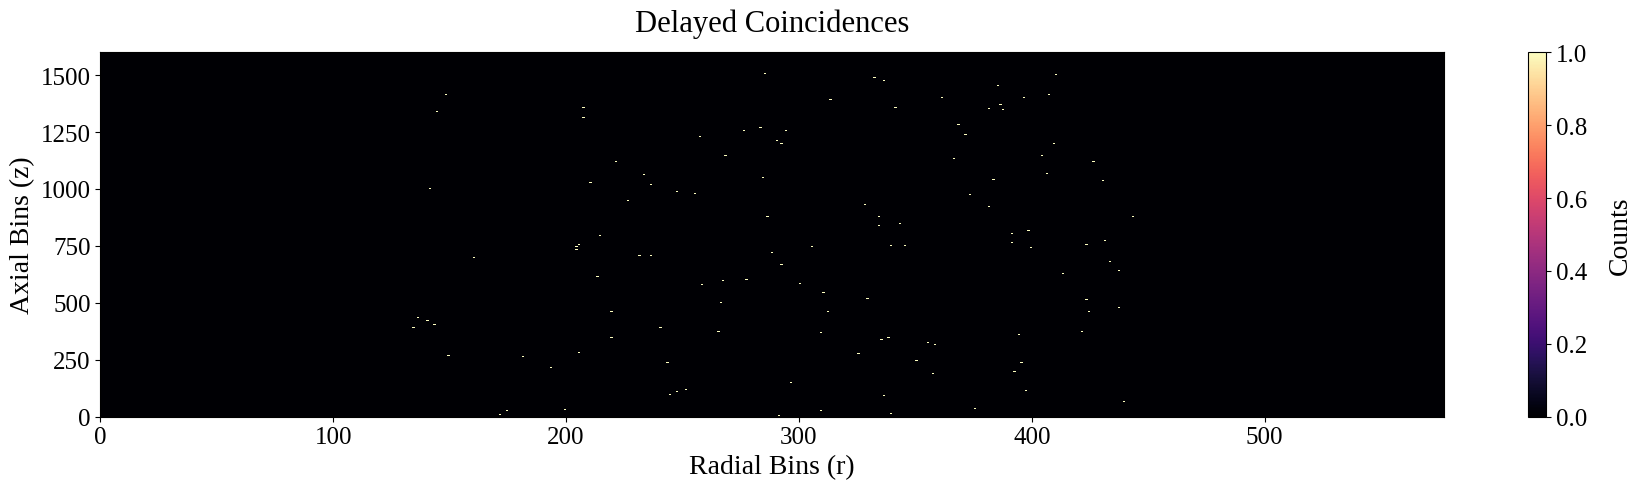

In [15]:
plt.figure(figsize=(18, 5)) # Increased height slightly to accommodate larger labels

# Plotting the sinogram
# Using .T if you want z to run vertically as per your comments
im = plt.pcolormesh(sinogram_delays[0,:,:].T, cmap='magma', shading='auto') 

# 1. Increase Title Size
plt.title('Delayed Coincidences', fontsize=22, pad=15)

# 2. Increase X and Y axis number (tick label) size
plt.tick_params(axis='both', which='major', labelsize=18)

# 3. Add Axis Labels (Optional but recommended for clarity)
plt.xlabel('Radial Bins (r)', fontsize=20)
plt.ylabel('Axial Bins (z)', fontsize=20)

# 4. Handle Colorbar label size
cbar = plt.colorbar(im)
cbar.ax.tick_params(labelsize=18) # This makes the numbers on the colorbar bigger
cbar.set_label('Counts', fontsize=20, labelpad=15)

plt.tight_layout()
plt.show()

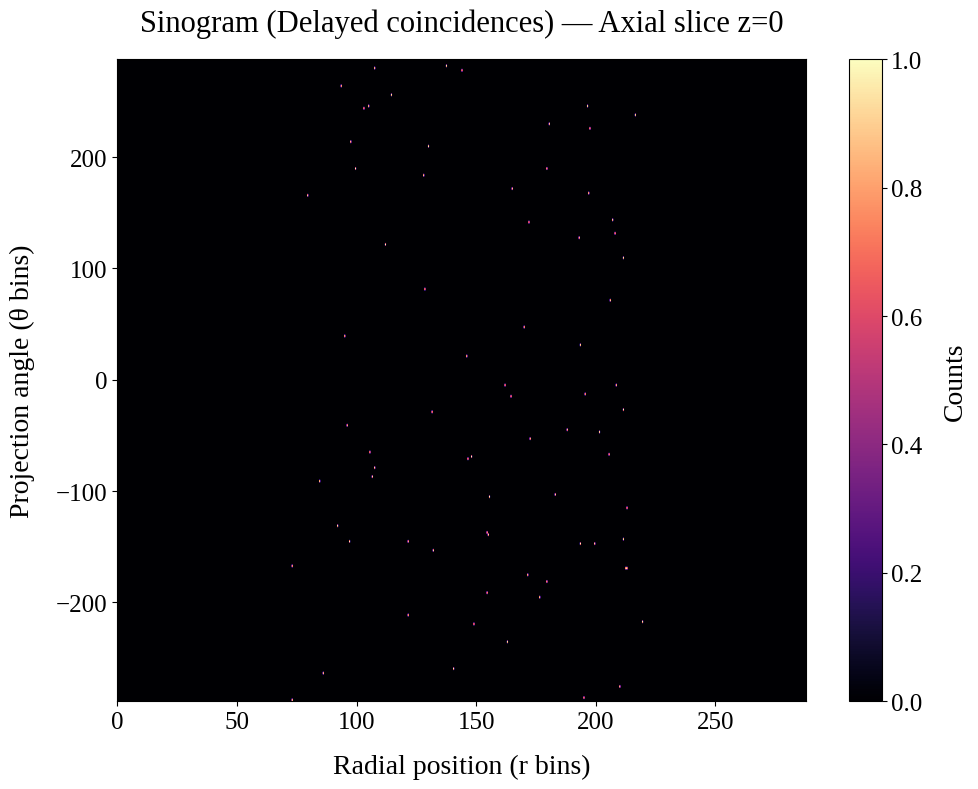

In [16]:
# choose one axial slice (e.g., middle of the scanner)
z_index = 0  
plt.figure(figsize=(10, 8)) # Slightly larger for better readability

# Plot θ–r plane
im = plt.imshow(
    sinogram_delays[:, :, z_index], 
    cmap='magma',
    aspect='auto',
    extent=[0, sinogram_delays.shape[0], 
            -sinogram_delays.shape[1]//2, sinogram_delays.shape[1]//2]
)

# 1. Increase Axis Label sizes
plt.ylabel("Projection angle (θ bins)", fontsize=20, labelpad=15)
plt.xlabel("Radial position (r bins)", fontsize=20, labelpad=15)
plt.title(f"Sinogram (Delayed coincidences) — Axial slice z={z_index}", fontsize=22, pad=20)

# 2. Increase X and Y axis number (tick label) size
plt.tick_params(axis='both', which='major', labelsize=18)

# 3. Enhance Colorbar
cbar = plt.colorbar(im)
cbar.set_label("Counts", fontsize=20, labelpad=15)
cbar.ax.tick_params(labelsize=18) # Makes colorbar numbers bigger

plt.tight_layout()
plt.show()

In [17]:
# Smooth the sinogram
# The 1st Gaussian is applied along θ
# The 2nd along r
# The 3rd and 4th along both z1 and z2
# Finally, it flattens back to (r, θ, z)
# Each kernel_size controls the number of pixels covered by the kernel.

sinogram_randoms_estimate = gate.smooth_randoms_sinogram(
    sinogram_delays, pet_info,
    sigma_r=3, # how far from the center a line of response (LOR) is
    sigma_theta=3, # the rotation angle around the scanner
    sigma_z=1.5, # which ring pair or axial slice you’re looking a
    kernel_size_r=15,
    kernel_size_theta=15,
    kernel_size_z=9
)
print(sinogram_randoms_estimate.shape)

torch.Size([288, 577, 1600])


In [18]:
print(f"sinogram_randoms_estimate range: [{sinogram_randoms_estimate.min():.6f}, {sinogram_randoms_estimate.max():.6f}]")

sinogram_randoms_estimate range: [0.000000, 0.020310]


In [19]:
# compare with the true randoms events
sinogram_randoms_true = gate.listmode_to_sinogram(detector_ids_true_randoms, pet_info)

In [20]:
sinogram_randoms_estimate_scaled = sinogram_randoms_estimate * (
    sinogram_randoms_true.max() / sinogram_randoms_estimate.max()
)

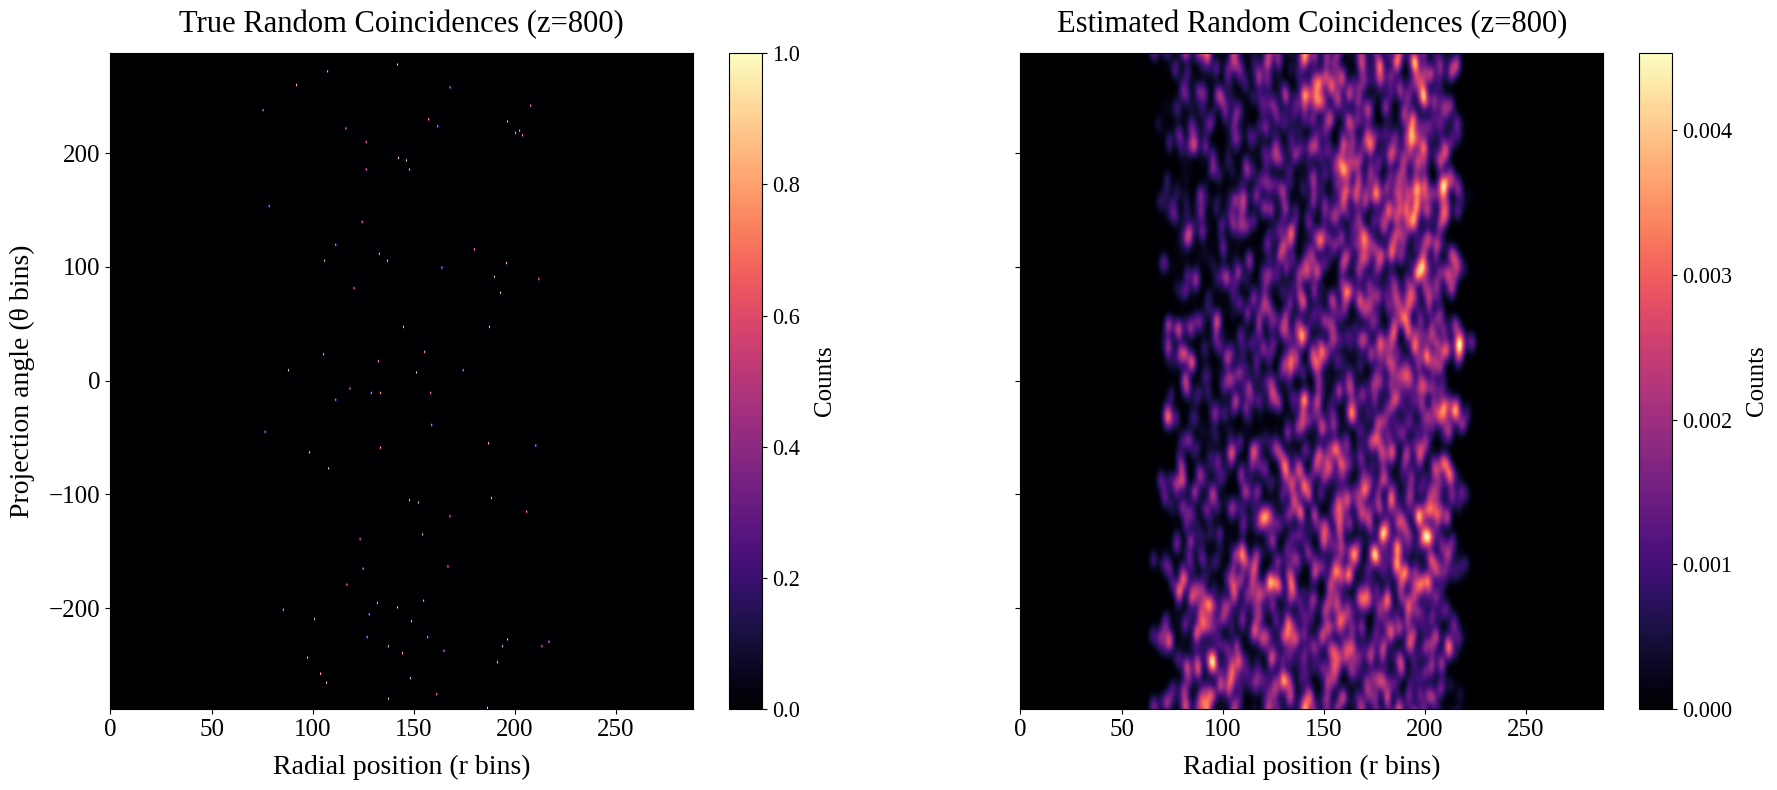

In [21]:
# Choose the same axial slice index for both
z_index = sinogram_randoms_true.shape[2] // 2 

fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

# --- True Randoms ---
im1 = axes[0].imshow(
    sinogram_randoms_true[:, :, z_index], 
    cmap='magma',
    aspect='auto',
    extent=[0, sinogram_randoms_true.shape[0],
            -sinogram_randoms_true.shape[1]//2, sinogram_randoms_true.shape[1]//2]
)
axes[0].set_title(f"True Random Coincidences (z={z_index})", fontsize=22, pad=15)
axes[0].set_xlabel("Radial position (r bins)", fontsize=20, labelpad=10)
axes[0].set_ylabel("Projection angle (θ bins)", fontsize=20, labelpad=10)

# Apply tick sizing to the first plot
axes[0].tick_params(axis='both', which='major', labelsize=18)
cbar1 = fig.colorbar(im1, ax=axes[0])
cbar1.set_label("Counts", fontsize=18, labelpad=10)
cbar1.ax.tick_params(labelsize=16)

# --- Estimated Randoms ---
im2 = axes[1].imshow(
    sinogram_randoms_estimate[:, :, z_index],
    cmap='magma',
    aspect='auto',
    extent=[0, sinogram_randoms_estimate.shape[0],
            -sinogram_randoms_estimate.shape[1]//2, sinogram_randoms_estimate.shape[1]//2]
)
axes[1].set_title(f"Estimated Random Coincidences (z={z_index})", fontsize=22, pad=15)
axes[1].set_xlabel("Radial position (r bins)", fontsize=20, labelpad=10)

# Apply tick sizing to the second plot
axes[1].tick_params(axis='both', which='major', labelsize=18)
cbar2 = fig.colorbar(im2, ax=axes[1])
cbar2.set_label("Counts", fontsize=18, labelpad=10)
cbar2.ax.tick_params(labelsize=16)



plt.tight_layout()
plt.subplots_adjust(wspace=0.25) # Increased wspace to prevent colorbar/title overlap
plt.show()

In [22]:
# Convert back to listmode
lm_delays = shared.sinogram_to_listmode(detector_total_ids, sinogram_randoms_estimate , pet_info)
print(lm_delays.shape)
print(f"lm_delays range: [{lm_delays.min():.6f}, {lm_delays.max():.6f}]")

torch.Size([8609228])
lm_delays range: [0.000000, 0.018214]


### Scatter Estimation via Listmode (PyTomography Workflow)

PyTomography performs **scatter estimation** using the **Single Scatter Simulation (SSS)** algorithm.
The general workflow consists of the following steps:

1. **Initial Reconstruction:**
   Reconstruct the PET data **without scatter correction**, but include **randoms estimation**, **attenuation**, and **normalization** corrections.
   This initial reconstruction serves as a proxy to estimate scatter.

2. **Incorporate Randoms Estimate:**
   Pass the **random listmode weights estimate** divided by the **sensitivity listmode weights** as an **additive term** in the likelihood function.

3. **Estimate Scatter via SSS:**
   Use the initial reconstruction to perform **scatter estimation** using the **SSS technique**.

4. **Convert to Listmode:**
   Transform the resulting **scatter sinogram** back into a **listmode file** for use in subsequent corrections.

---

### How the SSS Algorithm Works

1. Compute scatter estimates in **sparse sinogram space** (only a subset of detector pairs).
2. **Interpolate** the sparse sinogram to fill in missing values.
3. **Scale** the scatter tails to match measured data statistics.


In [23]:
## estimates scatters via the single scatter simulation (SSS) algorithm (w or w/o time of flight). 
# In order to use SSS, we need an initial reconstruction of the data (without scatter estimation). 
# We use this reconstruction as a proxy to estimate scatter.

object_meta_2 = ObjectMeta(
    dr=(2.21,2.21,2.21), # voxel size
    shape=(125,122,93) # dimensions
)

# reconstruct the data without scatter estimation (but using randoms)

atten_map = gate.get_aligned_attenuation_map(os.path.join(path, 'attenuation_image-HU.hdr'), object_meta_2).to(pytomography.device) # attenuation map
normalization_weights = torch.load(os.path.join(path, 'normalization_weights_noTOF.pt')) # upload normalization file
proj_meta_2 = PETLMProjMeta(
    detector_total_ids,  # total events
    pet_info,
    weights_sensitivity=normalization_weights # normalization
    )
psf_transform = GaussianFilter(6) # 6 PSF + 3 sigma
system_matrix = PETLMSystemMatrix(
       object_meta_2,
       proj_meta_2,
       obj2obj_transforms = [psf_transform],
       N_splits=10,
       attenuation_map=atten_map
)

In [24]:
# We’ll reconstruct only using randoms as an estimate. 
# We need to pass the random sinogram estimate from before divided by the sensitivty sinogram as an additive term estimate to the likelihood function:

# Get additive term (without scatter term):
lm_sensitivity = system_matrix._compute_sensitivity_projection(all_ids=False)
additive_term = lm_delays / lm_sensitivity
additive_term[additive_term.isnan()] = 0 # remove NaN values

# Reconstruction
likelihood = PoissonLogLikelihood(
        system_matrix,
        additive_term = additive_term
    )
# reconstruct using only random estimation
recon_algorithm = OSEM(likelihood)

recon_without_scatter_estimation = recon_algorithm(3,15)

In [25]:
print(recon_without_scatter_estimation.shape)
print(f"recon_without_scatter_estimation range: [{recon_without_scatter_estimation.min():.6f}, {recon_without_scatter_estimation.max():.6f}]")

torch.Size([125, 122, 93])
recon_without_scatter_estimation range: [0.000000, 22.924116]


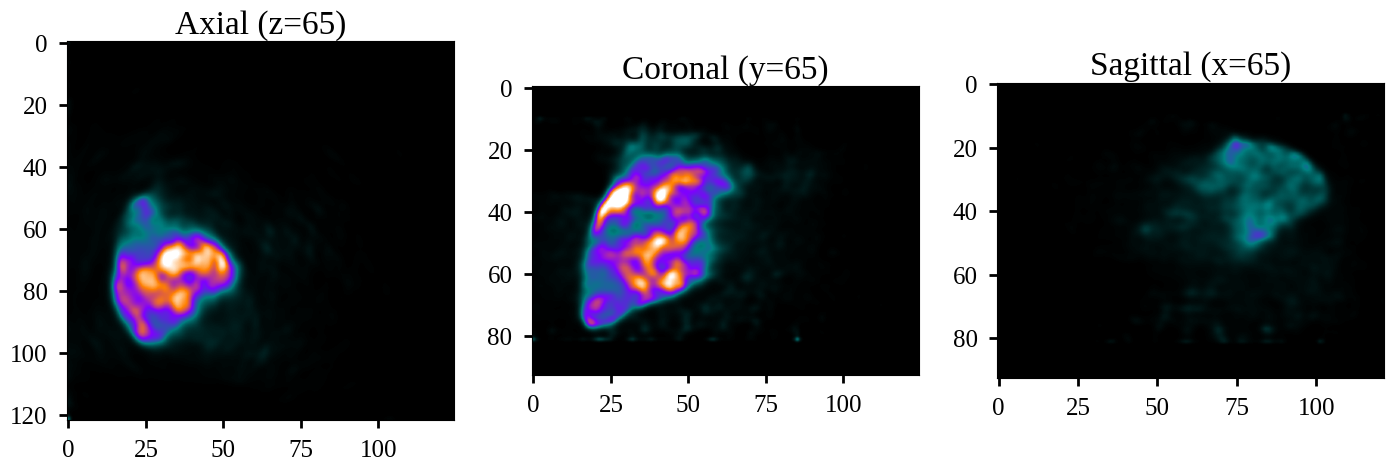

In [26]:
import matplotlib.colors as mcolors

# 1. Define your custom color list (positions from 0 to 1)
slicer_pet_colors = [
    (0.00, "#000000"),  # Black
    (0.25, "#008080"),  # Teal / Dark Cyan
    (0.50, "#8000ff"),  # Purple / Violet
    (0.75, "#ff8000"),  # Orange
    (1.00, "#ffffff")   # White
]

# 2. Create the custom colormap object
cmap = mcolors.LinearSegmentedColormap.from_list('SlicerPET', slicer_pet_colors)

vmax = 15
slice_idx = 65

fig, ax = plt.subplots(1, 3, figsize=(17, 8), gridspec_kw={'wspace': 0.2})

# Plotting each plane
ax[0].imshow(recon_without_scatter_estimation[:, :, slice_idx].cpu().T, cmap=cmap,
             interpolation='gaussian', vmax=vmax, origin='upper')
ax[0].set_title(f'Axial (z={slice_idx})', fontsize=24) # Increased title size too

ax[1].imshow(recon_without_scatter_estimation[:, slice_idx, :].cpu().T, cmap=cmap,
             interpolation='gaussian', vmax=vmax, origin='upper')
ax[1].set_title(f'Coronal (y={slice_idx})', fontsize=24)

ax[2].imshow(recon_without_scatter_estimation[slice_idx, :, :].cpu().T, cmap=cmap,
             interpolation='gaussian', vmax=vmax, origin='upper')
ax[2].set_title(f'Sagittal (x={slice_idx})', fontsize=24)

# --- INCREASE AXIS NUMBER SIZE ---
for a in ax:
    # labelsize adjusts the numbers; width/length adjusts the tick marks
    a.tick_params(axis='both', which='major', labelsize=18, width=2, length=6)
    # If you want to force specific spacing/padding between numbers and the plot:
    a.tick_params(axis='both', pad=8)

fig.tight_layout()
plt.subplots_adjust(wspace=0.3) # Adjusted slightly for larger labels
plt.show()

In [27]:
# This reconstruction is then used to estimate scatter in the SSS scatter estimation technique. 
sinogram_scatter = sss.get_sss_scatter_estimate(
    object_meta = object_meta_2,
    proj_meta = proj_meta_2, # required for the scaling of the scatter tails.
    pet_image = recon_without_scatter_estimation,  # the initial activity estimation which is used to estimate the scatter contribution.
    attenuation_image = atten_map, # used to compute compton cross sections
    system_matrix = system_matrix, # needed for the scaling of the scatter tails.
    proj_data = None, # assumes listmode
    image_stepsize = 4, # stepsize in x/y/z used for subsampling voxels in object space for the scatter simulation. DEFAULT VALUE
    attenuation_cutoff = 0.001,  # is used for two purposes: (i) any scatter point below this value is not considered and (ii) when the attenuation map is forward projected as a mask to scale the scatter tails, this is the cutoff value for the mask
    sinogram_interring_stepsize = 4, # the axial (between rings) stepsize between detector crystals used as sample points in the scatter simulation
    sinogram_intraring_stepsize = 4, # the transaxial stepsize between detector crystals used as sample points in the scatter simulation.
    sinogram_random = sinogram_randoms_estimate, # required for scaling the scatter tails at the end.
    N_splits = 4 # Increase only if memory issues
    )

[SSS] Starting scatter estimate...
[SSS] Listmode: True
[SSS] Computing sparse sinogram (non-TOF)...
[SSS] Attenuation map range: tensor(1.1211e-05, device='cuda:0') tensor(0.0235, device='cuda:0')
[SSS] Sparse sinogram shape: torch.Size([288, 577, 1600])
[SSS] Sparse sinogram: tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0

In [39]:
print(f"Estimated scatter sinogram range: [{sinogram_scatter.min():.6f}, {sinogram_scatter.max():.6f}]")

Estimated scatter sinogram range: [-0.000037, 0.057175]


In [40]:
# Now convert to listmode
lm_scatter = shared.sinogram_to_listmode(proj_meta_2.detector_ids, sinogram_scatter, proj_meta_2.info)
print(lm_scatter.shape)

torch.Size([8609228])


In [41]:
# true scatters upload
sinogram_scatters_true = gate.listmode_to_sinogram(detector_ids_true_scatters, pet_info)

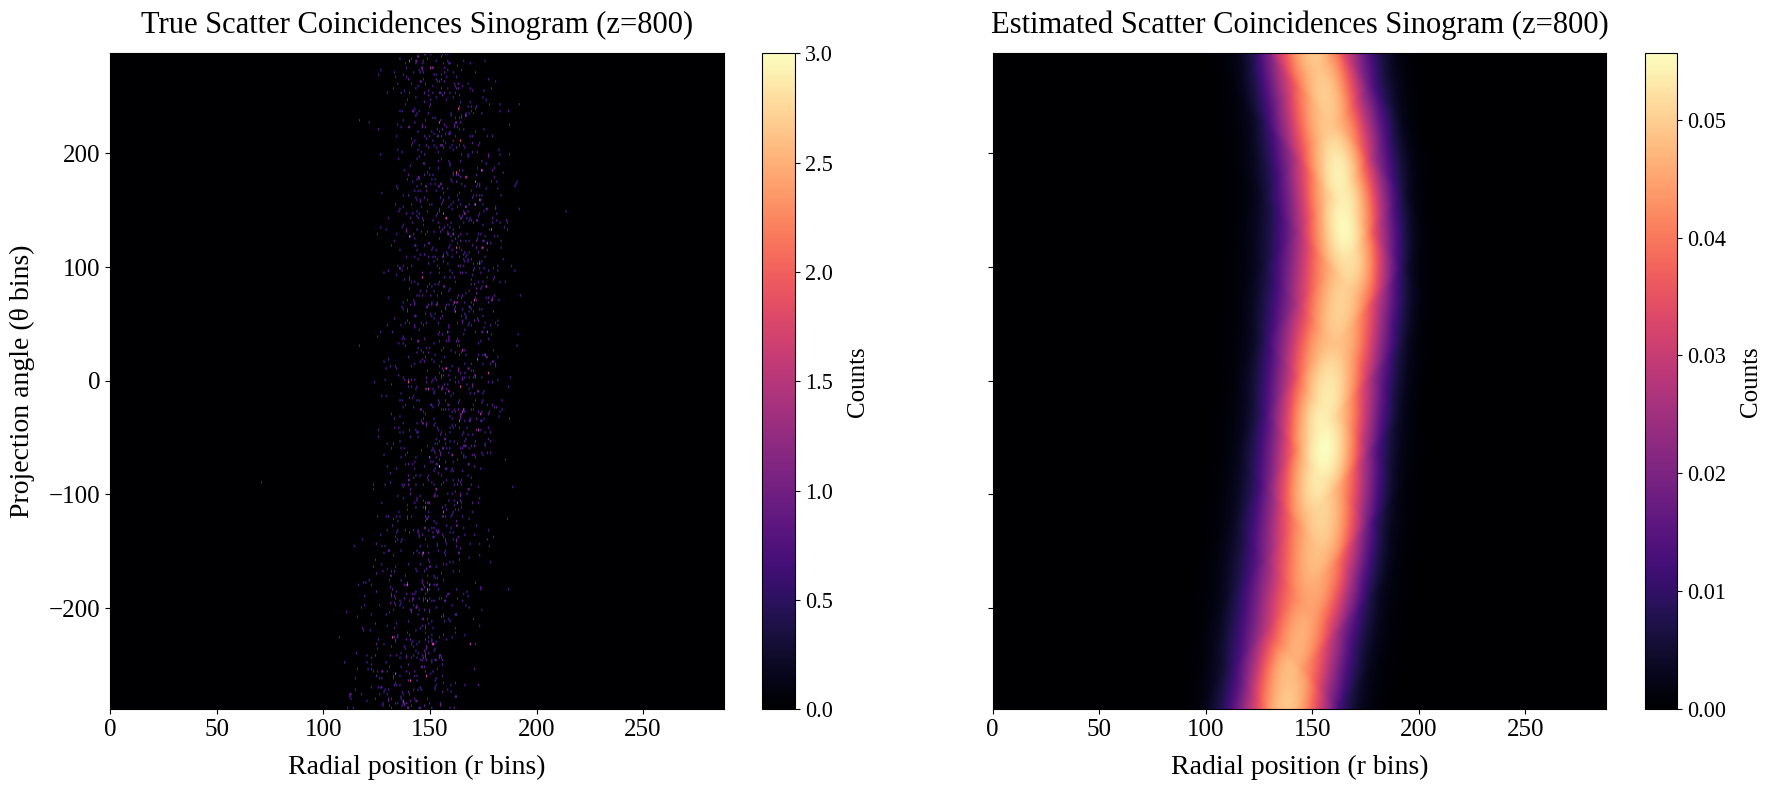

In [47]:
import matplotlib.pyplot as plt

# Choose the same axial slice index for both (e.g., middle of the scanner)
z_index = sinogram_scatters_true.shape[2] // 2 # or sinogram_delays.shape[2] // 2 for middle

ffig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

# --- True Randoms ---
im1 = axes[0].imshow(
    sinogram_scatters_true[:, :, z_index], # transpose so r is vertical if you prefer .T
    cmap='magma',
    aspect='auto',
    extent=[0, sinogram_scatters_true.shape[0],
            -sinogram_scatters_true.shape[1]//2, sinogram_scatters_true.shape[1]//2]
)
axes[0].set_title(f"True Scatter Coincidences Sinogram (z={z_index})", fontsize=22, pad=15)
axes[0].set_xlabel("Radial position (r bins)", fontsize=20, labelpad=10)
axes[0].set_ylabel("Projection angle (θ bins)", fontsize=20, labelpad=10)

# Apply tick sizing to the first plot
axes[0].tick_params(axis='both', which='major', labelsize=18)
cbar1 = fig.colorbar(im1, ax=axes[0])
cbar1.set_label("Counts", fontsize=18, labelpad=10)
cbar1.ax.tick_params(labelsize=16)

# --- Estimated Randoms ---
im2 = axes[1].imshow(
    sinogram_scatter[:, :, z_index], # (r, θ, z)
    cmap='magma',
    aspect='auto',
    extent=[0, sinogram_scatter.shape[0],
            -sinogram_scatter.shape[1]//2, sinogram_scatter.shape[1]//2]
)
axes[1].set_title(f"Estimated Scatter Coincidences Sinogram (z={z_index})", fontsize=22, pad=15)
axes[1].set_xlabel("Radial position (r bins)",fontsize=20, labelpad=10)

# Apply tick sizing to the second plot
axes[1].tick_params(axis='both', which='major', labelsize=18)
cbar2 = fig.colorbar(im2, ax=axes[1])
cbar2.set_label("Counts", fontsize=18, labelpad=10)
cbar2.ax.tick_params(labelsize=16)

plt.tight_layout()
plt.subplots_adjust(wspace=0.15) # Increased wspace to prevent colorbar/title overlap
plt.show()

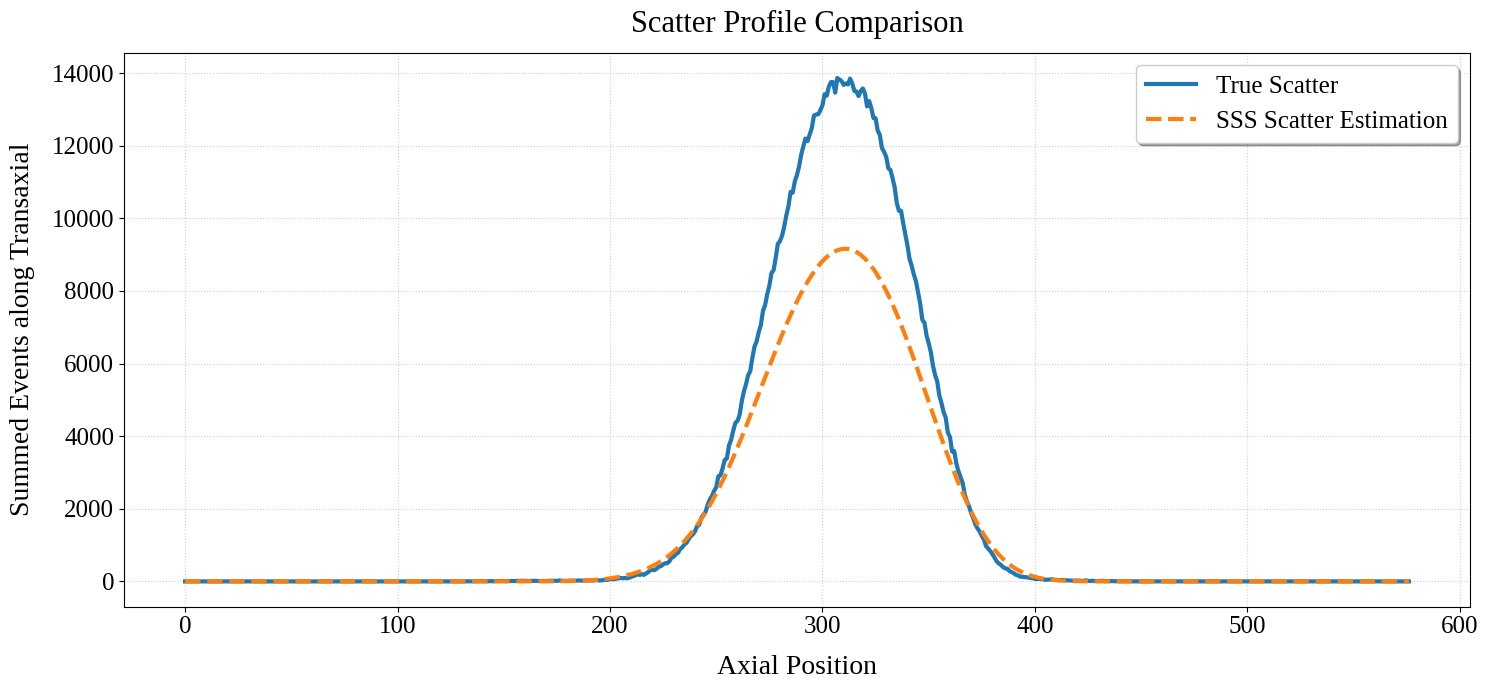

In [48]:
plt.figure(figsize=(15, 7)) # Increased width and height

# Increase linewidth so the lines are clearly visible with the larger labels
plt.plot(sinogram_scatters_true[:,:,:800].sum(dim=(0,2)), 
         label='True Scatter', linewidth=3)
plt.plot(sinogram_scatter[:,:,:800].sum(dim=(0,2)), 
         ls='--', label='SSS Scatter Estimation', linewidth=3)

# 1. Increase Axis Label sizes
plt.xlabel('Axial Position', fontsize=20, labelpad=12)
plt.ylabel('Summed Events along Transaxial', fontsize=20, labelpad=12)

# 2. Increase Title (Optional)
plt.title('Scatter Profile Comparison', fontsize=22, pad=15)

# 3. Increase X and Y axis number (tick label) size
plt.tick_params(axis='both', which='major', labelsize=18)

# 4. Increase Legend size
plt.legend(fontsize=18, frameon=True, shadow=True)

# Add a grid for easier value comparison
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### Reconstruction with All Corrections (randoms, scatter, normalization and attenuation correction) - 3i15s

Now that we have the randoms and scatter estimation, the reconstruction with all corrections can be done. The additive term to the likelihood is the sum of randoms + scatters estimation divided by the sensitivty sinogram.

In [33]:
# we can redefine our additive term to include scatter information and reconstruct:
# Specify where to save the files FIRST
save_directory = "/home/administrator/Secretária/ResultsY90/results_notof_primary_scatter_and_random_correction"
os.makedirs(save_directory, exist_ok=True)
print(f"Files will be saved to: {save_directory}")

additive_term = (lm_scatter + lm_delays) / lm_sensitivity # include randoms and scatters
additive_term[additive_term.isnan()] = 0
likelihood = PoissonLogLikelihood(
        system_matrix,
        additive_term = additive_term ## scatters and randoms corrections
    )
recon_algorithm = OSEM(likelihood)

## CALLBACK TO SAVE RESULTS

# Create DataStorageCallback to save all iterations
data_storage_callback = DataStorageCallback(likelihood, torch.clone(recon_algorithm.object_prediction))

recon_lm_nontof = recon_algorithm(3, 15, callback=data_storage_callback)

Files will be saved to: /home/administrator/Secretária/ResultsY90/results_notof_primary_scatter_and_random_correction


#### Visualise final image result

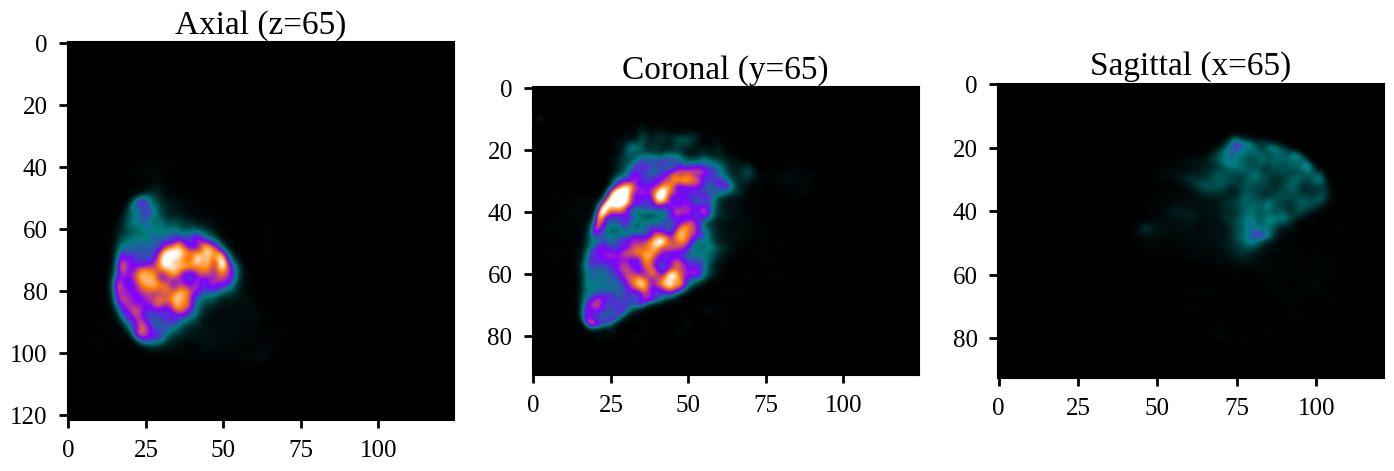

In [49]:
import matplotlib.colors as mcolors

# 1. Define your custom color list (positions from 0 to 1)
slicer_pet_colors = [
    (0.00, "#000000"),  # Black
    (0.25, "#008080"),  # Teal / Dark Cyan
    (0.50, "#8000ff"),  # Purple / Violet
    (0.75, "#ff8000"),  # Orange
    (1.00, "#ffffff")   # White
]

# 2. Create the custom colormap object
cmap = mcolors.LinearSegmentedColormap.from_list('SlicerPET', slicer_pet_colors)

vmax = 15
slice_idx = 65

fig, ax = plt.subplots(1, 3, figsize=(17, 8), gridspec_kw={'wspace': 0.2})

# Plotting each plane
ax[0].imshow(recon_lm_nontof[:, :, slice_idx].cpu().T, cmap=cmap,
             interpolation='gaussian', vmax=vmax, origin='upper')
ax[0].set_title(f'Axial (z={slice_idx})', fontsize=24) # Increased title size too

ax[1].imshow(recon_lm_nontof[:, slice_idx, :].cpu().T, cmap=cmap,
             interpolation='gaussian', vmax=vmax, origin='upper')
ax[1].set_title(f'Coronal (y={slice_idx})', fontsize=24)

ax[2].imshow(recon_lm_nontof[slice_idx, :, :].cpu().T, cmap=cmap,
             interpolation='gaussian', vmax=vmax, origin='upper')
ax[2].set_title(f'Sagittal (x={slice_idx})', fontsize=24)

# --- INCREASE AXIS NUMBER SIZE ---
for a in ax:
    # labelsize adjusts the numbers; width/length adjusts the tick marks
    a.tick_params(axis='both', which='major', labelsize=18, width=2, length=6)
    # If you want to force specific spacing/padding between numbers and the plot:
    a.tick_params(axis='both', pad=8)

fig.tight_layout()
plt.subplots_adjust(wspace=0.3) # Adjusted slightly for larger labels
plt.show()

In [50]:
import nibabel as nib
import torch
import numpy as np
import os

# --- SETTINGS ---
n_subsets = 15
n_main_iters = 3  # total OSEM iterations
save_directory = "/home/administrator/Secretária/ResultsY90/Results_all_corrections_3i15s"
os.makedirs(save_directory, exist_ok=True)
print(f"Files will be saved to: {save_directory}\n")

# --- FILTER MAIN ITERATIONS ---
main_iterations = []
print(f"Total objects in callback: {len(data_storage_callback.objects)}")

for i in range(n_main_iters):
    main_idx = (i * n_subsets) + (n_subsets - 1)  # last subset of each iteration
    if main_idx < len(data_storage_callback.objects):
        main_iterations.append(data_storage_callback.objects[main_idx])
        print(f"Main iteration {i+1} found at index {main_idx}")
    else:
        print(f" Warning: Main iteration {i+1} index {main_idx} out of range")

print(f"\nFiltered {len(data_storage_callback.objects)} total objects → {len(main_iterations)} main iterations.\n")

# --- VOXEL METADATA ---
voxel_size = object_meta.dr  # (dx, dy, dz)
print(f"Voxel size: {voxel_size}")

# --- PROCESS AND SAVE EACH MAIN ITERATION ---
for i, tensor in enumerate(main_iterations, start=1):
    recon_np = tensor.detach().cpu().numpy()

    # --- FIX ORIENTATION ---
    recon_np = np.flip(recon_np, axis=1)  # flip Y
    recon_np = np.flip(recon_np, axis=0)  # flip X
    recon_np = np.flip(recon_np, axis=2)  # flip Z

    # --- CREATE AFFINE ---
    affine = np.diag([voxel_size[0], voxel_size[1], voxel_size[2], 1])

    # --- CREATE NIFTI ---
    nifti_img = nib.Nifti1Image(recon_np, affine)
    nifti_img.header.set_zooms(voxel_size)
    nifti_img.header['descrip'] = f"OSEM reconstruction - Iteration {i} (flipped X,Y,Z)"

    # --- SAVE ---
    file_path = os.path.join(save_directory, f"reconstruction_iteration_{i}.nii")
    nib.save(nifti_img, file_path)
    print(f"Saved main iteration {i} to: {file_path}")

# --- VERIFY FILES ---
print(f"\nChecking files in: {save_directory}")
for file in os.listdir(save_directory):
    if file.startswith("reconstruction_iteration_") and file.endswith(".nii"):
        file_path = os.path.join(save_directory, file)
        size_mb = os.path.getsize(file_path) / (1024 * 1024)
        print(f"  {file} ({size_mb:.2f} MB)")

print("\n All main iteration files created with correct orientation and affine matrix.")

Files will be saved to: /home/administrator/Secretária/ResultsY90/Results_all_corrections_3i15s

Total objects in callback: 46
Main iteration 1 found at index 14
Main iteration 2 found at index 29
Main iteration 3 found at index 44

Filtered 46 total objects → 3 main iterations.

Voxel size: (2.21, 2.21, 2.21)
Saved main iteration 1 to: /home/administrator/Secretária/ResultsY90/Results_all_corrections_3i15s/reconstruction_iteration_1.nii
Saved main iteration 2 to: /home/administrator/Secretária/ResultsY90/Results_all_corrections_3i15s/reconstruction_iteration_2.nii
Saved main iteration 3 to: /home/administrator/Secretária/ResultsY90/Results_all_corrections_3i15s/reconstruction_iteration_3.nii

Checking files in: /home/administrator/Secretária/ResultsY90/Results_all_corrections_3i15s
  reconstruction_iteration_1.nii (5.41 MB)
  reconstruction_iteration_2.nii (5.41 MB)
  reconstruction_iteration_3.nii (5.41 MB)

 All main iteration files created with correct orientation and affine matrix

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import os
from matplotlib.colors import LinearSegmentedColormap
from ipywidgets import interact, IntSlider, widgets

# ============================================================
# 1. Path Configuration & Data Loading
# ============================================================
# Updated to your "Results_all_corrections_3i15s" path
base_dir = os.path.expanduser("/home/administrator/Secretária/ResultsY90/Results_all_corrections_3i15s")

# Load 3 iterations dynamically
recon_paths = [os.path.join(base_dir, f"reconstruction_iteration_{i}.nii") for i in range(1, 4)]

iterations_data = []
iterations_labels = []

for idx, file_path in enumerate(recon_paths, start=1):
    if os.path.exists(file_path):
        img = nib.load(file_path)
        iterations_data.append(img.get_fdata())
        iterations_labels.append(f'Iteration {idx}')
    else:
        print(f"Warning: File not found - {file_path}")

if not iterations_data:
    raise RuntimeError("No reconstruction files were loaded. Please check the base_dir path.")

# ============================================================
# 2. Custom Colormap Definition (3D Slicer "PET-DICOM")
# ============================================================
slicer_pet_colors = [
    (0.00, "#000000"),  # 0%: Black
    (0.25, "#008080"),  # 25%: Teal / Dark Cyan
    (0.50, "#8000ff"),  # 50%: Purple / Violet
    (0.75, "#ff8000"),  # 75%: Orange
    (1.00, "#ffffff")   # 100%: White
]
pet_cmap = LinearSegmentedColormap.from_list("Slicer_PET_DICOM", slicer_pet_colors)

# ============================================================
# 3. Enhanced Visualization Function
# ============================================================
def plot_all_corrections_enhanced(axial_slice=None, sagittal_slice=None, coronal_slice=None, individual_scaling=False):
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Liberation Serif"],
        "mathtext.fontset": "dejavuserif",
    })

    # Slice defaults (Mapping dims based on NIfTI shape)
    x_dim, y_dim, z_dim = iterations_data[0].shape
    sagittal_slice = sagittal_slice if sagittal_slice is not None else x_dim // 2
    coronal_slice = coronal_slice if coronal_slice is not None else y_dim // 2
    axial_slice = axial_slice if axial_slice is not None else z_dim // 2

    # Scaling logic
    fixed_vmax = 13.9  
    if individual_scaling:
        vmax_values = [np.percentile(d, 99.8) for d in iterations_data]
    else:
        vmax_values = [fixed_vmax] * len(iterations_data)

    num_iter = len(iterations_data)
    fig, axes = plt.subplots(num_iter, 3, figsize=(16, 4 * num_iter))
    
    # Adjusted left margin to 0.18 to fit the larger fontsize=18 iteration labels
    fig.subplots_adjust(top=0.88, bottom=0.08, left=0.18, right=0.9, wspace=0.03, hspace=0.08)

    for row, (data, label, vmax) in enumerate(zip(iterations_data, iterations_labels, vmax_values)):
        # Sagittal (X-Slice)
        sagittal_img = np.rot90(data[sagittal_slice, :, :]) 
        axes[row, 0].imshow(sagittal_img, cmap=pet_cmap, vmin=0, vmax=vmax,
                            interpolation='bicubic', origin='upper', aspect='auto')
        axes[row, 0].axis('off')

        # Coronal (Y-Slice)
        coronal_img = np.rot90(np.flip(data[:, coronal_slice, :], axis=0))
        axes[row, 1].imshow(coronal_img, cmap=pet_cmap, vmin=0, vmax=vmax,
                            interpolation='bicubic', origin='upper', aspect='auto')
        axes[row, 1].axis('off')

        # Axial (Z-Slice)
        axial_img = np.rot90(np.flip(data[:, :, axial_slice], axis=0))
        im = axes[row, 2].imshow(axial_img, cmap=pet_cmap, vmin=0, vmax=vmax,
                                 interpolation='bicubic', origin='upper', aspect='auto')
        axes[row, 2].axis('off')

        # Large Vertical Labels (Iteration names)
        bbox = axes[row, 0].get_position()
        y_center = (bbox.y0 + bbox.y1) / 2
        fig.text(0.06, y_center, label, fontsize=18, weight='bold', rotation=90, 
                 va='center', ha='center',
                 bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="black", alpha=0.8))

    # Column titles for the top row
    titles = [f'Sagittal (X={sagittal_slice})', f'Coronal (Y={coronal_slice})', f'Axial (Z={axial_slice})']
    for i, title in enumerate(titles):
        axes[0, i].set_title(title, fontsize=14, pad=15, weight='bold')

    plt.suptitle('OSEM All Corrections Reconstruction: Iteration Comparison (3i:15s)', 
                 fontsize=18, weight='bold', y=0.96)

    # Standardized Shared Colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    custom_ticks = [0.0, 3.5, 6.9, 10.4, 13.9]
    cbar = fig.colorbar(im, cax=cbar_ax, ticks=custom_ticks, format='%.1f')
    cbar.set_label('Intensity', labelpad=20, fontsize=18, weight='bold')
    cbar.ax.tick_params(labelsize=14)

    plt.show()

# ============================================================
# 4. Interactive Widgets
# ============================================================
x_dim, y_dim, z_dim = iterations_data[0].shape

interact(
    plot_all_corrections_enhanced,
    sagittal_slice=IntSlider(min=0, max=x_dim-1, step=1, value=x_dim//2, description='Sagittal:'),
    coronal_slice=IntSlider(min=0, max=y_dim-1, step=1, value=y_dim//2, description='Coronal:'),
    axial_slice=IntSlider(min=0, max=z_dim-1, step=1, value=z_dim//2, description='Axial:'),
    individual_scaling=widgets.Checkbox(value=False, description='Individual Scaling')
);

interactive(children=(IntSlider(value=46, description='Axial:', max=92), IntSlider(value=62, description='Sagi…

### Comparison between True Coincidences Reconstruction and All Corrections Reconstruction - 3i:15s

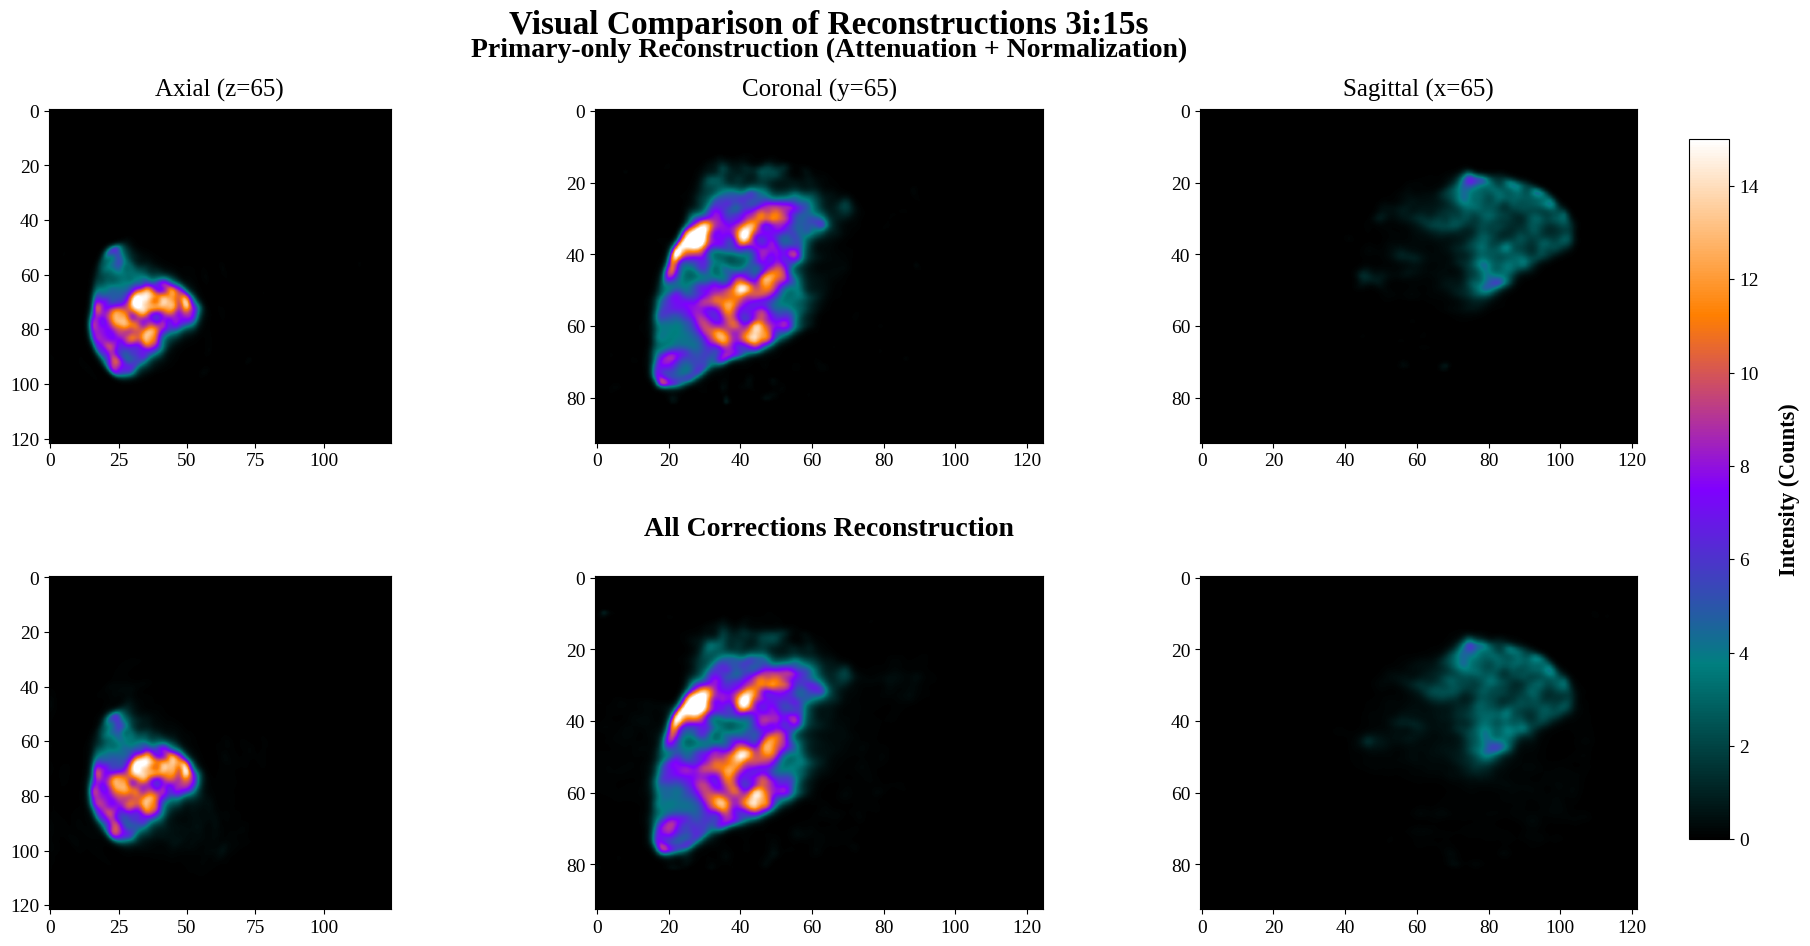

In [52]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 1. Define and create the custom Slicer PET colormap
slicer_pet_colors = [
    (0.00, "#000000"),  # 0%: Black
    (0.25, "#008080"),  # 25%: Teal / Dark Cyan
    (0.50, "#8000ff"),  # 50%: Purple / Violet
    (0.75, "#ff8000"),  # 75%: Orange
    (1.00, "#ffffff")   # 100%: White
]
pet_cmap = mcolors.LinearSegmentedColormap.from_list("SlicerPET", slicer_pet_colors)

vmax = 15
slice_idx = 65 

# Increase base padding and figure size for larger labels
fig, ax = plt.subplots(2, 3, figsize=(20, 10), gridspec_kw={'wspace': 0.3, 'hspace': 0.4})

# --------------------------------------------------------
# TOP ROW — Primary-only reconstruction
# --------------------------------------------------------
ax[0, 0].imshow(recon_trues_only[:, :, slice_idx].cpu().T, cmap=pet_cmap,
                interpolation='gaussian', vmax=vmax, origin='upper')
ax[0, 0].set_title(f'Axial (z={slice_idx})', fontsize=18, pad=10)

ax[0, 1].imshow(recon_trues_only[:, slice_idx, :].cpu().T, cmap=pet_cmap,
                interpolation='gaussian', vmax=vmax, origin='upper')
ax[0, 1].set_title(f'Coronal (y={slice_idx})', fontsize=18, pad=10)

ax[0, 2].imshow(recon_trues_only[slice_idx, :, :].cpu().T, cmap=pet_cmap,
                interpolation='gaussian', vmax=vmax, origin='upper')
ax[0, 2].set_title(f'Sagittal (x={slice_idx})', fontsize=18, pad=10)

# --------------------------------------------------------
# BOTTOM ROW — All-corrections reconstruction
# --------------------------------------------------------
ax[1, 0].imshow(recon_lm_nontof[:, :, slice_idx].cpu().T, cmap=pet_cmap,
                interpolation='gaussian', vmax=vmax, origin='upper')

ax[1, 1].imshow(recon_lm_nontof[:, slice_idx, :].cpu().T, cmap=pet_cmap,
                interpolation='gaussian', vmax=vmax, origin='upper')

ax[1, 2].imshow(recon_lm_nontof[slice_idx, :, :].cpu().T, cmap=pet_cmap,
                interpolation='gaussian', vmax=vmax, origin='upper')

# Apply bigger tick labels to all subplots
for a in ax.flat:
    a.tick_params(axis='both', which='major', labelsize=14)
    a.axis('on')

# --------------------------------------------------------
# Labels & Titles
# --------------------------------------------------------
fig.text(0.5, 0.94, "Primary-only Reconstruction (Attenuation + Normalization)", 
         ha='center', va='center', fontsize=20, weight='bold')

fig.text(0.5, 0.46, "All Corrections Reconstruction", 
         ha='center', va='center', fontsize=20, weight='bold')

fig.suptitle("Visual Comparison of Reconstructions 3i:15s", fontsize=24, weight='bold', y=0.98)

# Add a shared colorbar for the whole figure
im = ax[0,0].images[0]
cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Intensity (Counts)', fontsize=16, weight='bold', labelpad=15)

plt.subplots_adjust(top=0.88, bottom=0.08, left=0.08, right=0.91, wspace=0.3, hspace=0.4)
plt.show()